In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Explor the Dataset

In [36]:
df = pd.read_csv('/content/customer_churn_1M.csv')
df.head()


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


In [37]:
df.drop(columns=['customer_id'], inplace=True)
df.head()

,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,electronic_check,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,bank_transfer,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,credit_card,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,bank_transfer,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,credit_card,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


In [38]:
df.shape

(1000000, 31)

In [39]:
df.columns

Index(['signup_date', 'age', 'gender', 'annual_income', 'education',
       'marital_status', 'dependents', 'tenure', 'contract', 'payment_method',
       'paperless_billing', 'senior_citizen', 'monthlycharges', 'totalcharges',
       'num_services', 'has_phone_service', 'has_internet_service',
       'has_online_security', 'has_online_backup', 'has_device_protection',
       'has_tech_support', 'has_streaming_tv', 'has_streaming_movies',
       'customer_satisfaction', 'num_complaints', 'num_service_calls',
       'late_payments', 'avg_monthly_gb', 'days_since_last_interaction',
       'credit_score', 'churn'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 31 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   signup_date                  1000000 non-null  object 
 1   age                          1000000 non-null  int64  
 2   gender                       1000000 non-null  object 
 3   annual_income                970041 non-null   float64
 4   education                    1000000 non-null  object 
 5   marital_status               1000000 non-null  object 
 6   dependents                   1000000 non-null  int64  
 7   tenure                       1000000 non-null  int64  
 8   contract                     1000000 non-null  object 
 9   payment_method               1000000 non-null  object 
 10  paperless_billing            1000000 non-null  object 
 11  senior_citizen               1000000 non-null  int64  
 12  monthlycharges               1000000 non-nu

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,44.724603,14.479468,18.0,34.00,44.00,55.00,90.000000
annual_income,970041.0,58788.311936,37137.433079,20000.0,32712.56,48954.60,73475.13,250000.000000
dependents,1000000.0,0.799831,0.893654,0.0,0.00,1.00,1.00,5.000000
tenure,1000000.0,22.381923,20.073341,1.0,6.00,16.00,33.00,72.000000
senior_citizen,1000000.0,0.199511,0.399633,0.0,0.00,0.00,0.00,1.000000
monthlycharges,1000000.0,86.443701,27.592430,20.0,70.49,85.48,100.68,854.956730
totalcharges,1000000.0,1837.321438,1803.721634,16.3,484.53,1249.75,2617.66,16252.861508
num_services,1000000.0,2.563721,1.412330,1.0,1.00,2.00,3.00,6.000000
has_phone_service,1000000.0,0.769551,0.421120,0.0,1.00,1.00,1.00,1.000000
has_internet_service,1000000.0,0.849742,0.357324,0.0,1.00,1.00,1.00,1.000000


In [42]:
df.describe(include='object')

,signup_date,gender,education,marital_status,contract,payment_method,paperless_billing
count,1000000,1000000,1000000,1000000,1000000,1000000,1000000
unique,1000000,3,5,4,3,4,2
top,2025-05-15 12:54:09.482345,Male,bachelor,married,one_year,credit_card,Yes
freq,1,490166,300324,450115,550468,349706,749880


# Check Duplications and Null Values

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
avg_monthly_gb,5.0012
credit_score,4.0395
annual_income,2.9959
num_complaints,2.9906
customer_satisfaction,1.9921
age,0.0000
signup_date,0.0000
tenure,0.0000
contract,0.0000
payment_method,0.0000


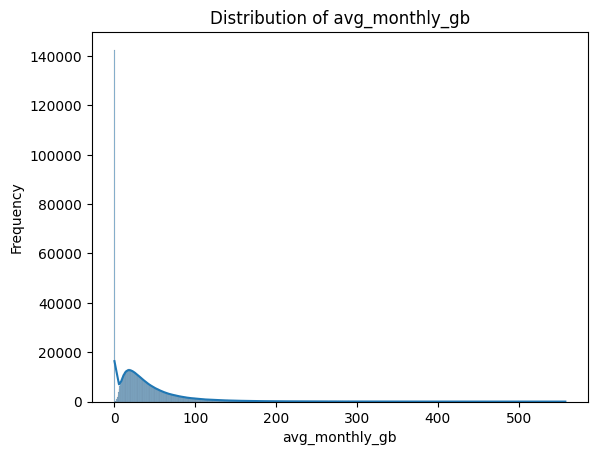

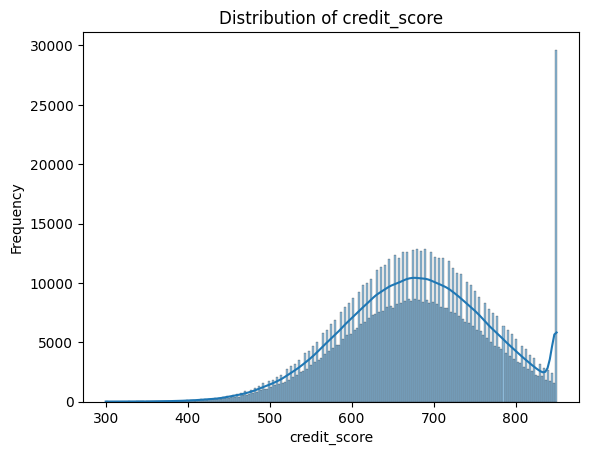

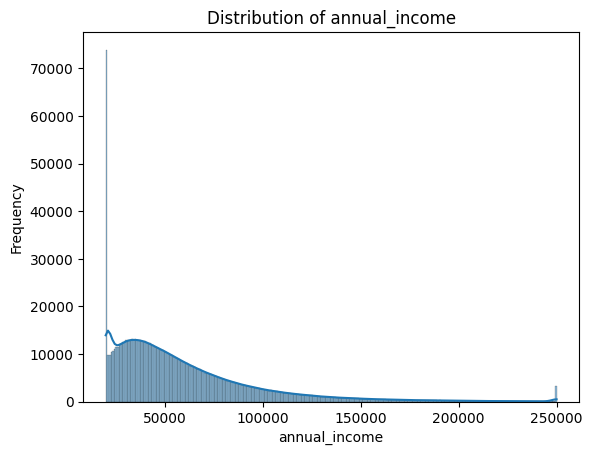

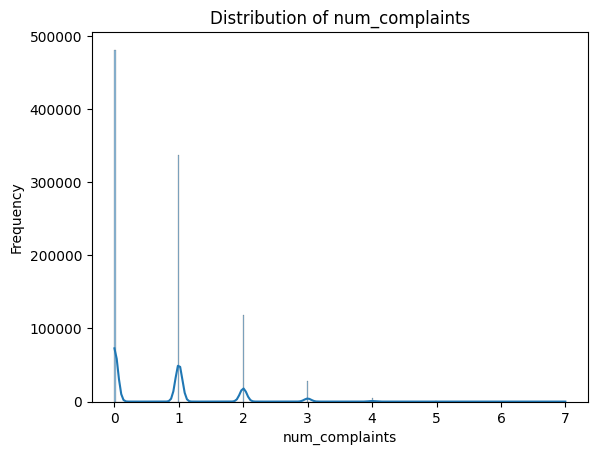

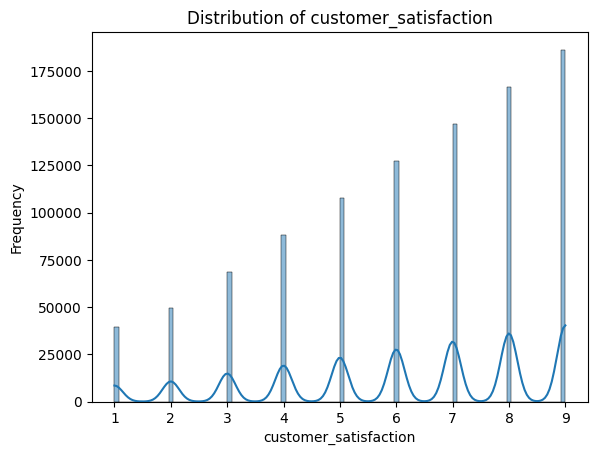

In [45]:
subplots = df[['avg_monthly_gb', 'credit_score', 'annual_income', 'num_complaints','customer_satisfaction']]
for col in subplots:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Check outliers
* IQR = Q3 - Q1
* max = (Q3 + 1.5 * IQR) or (mean + 3 * SD)
* min = (Q1 - 1.5 * IQR) or (mean - 3 * SD)

In [46]:
len(df.select_dtypes(include='number').columns)

24

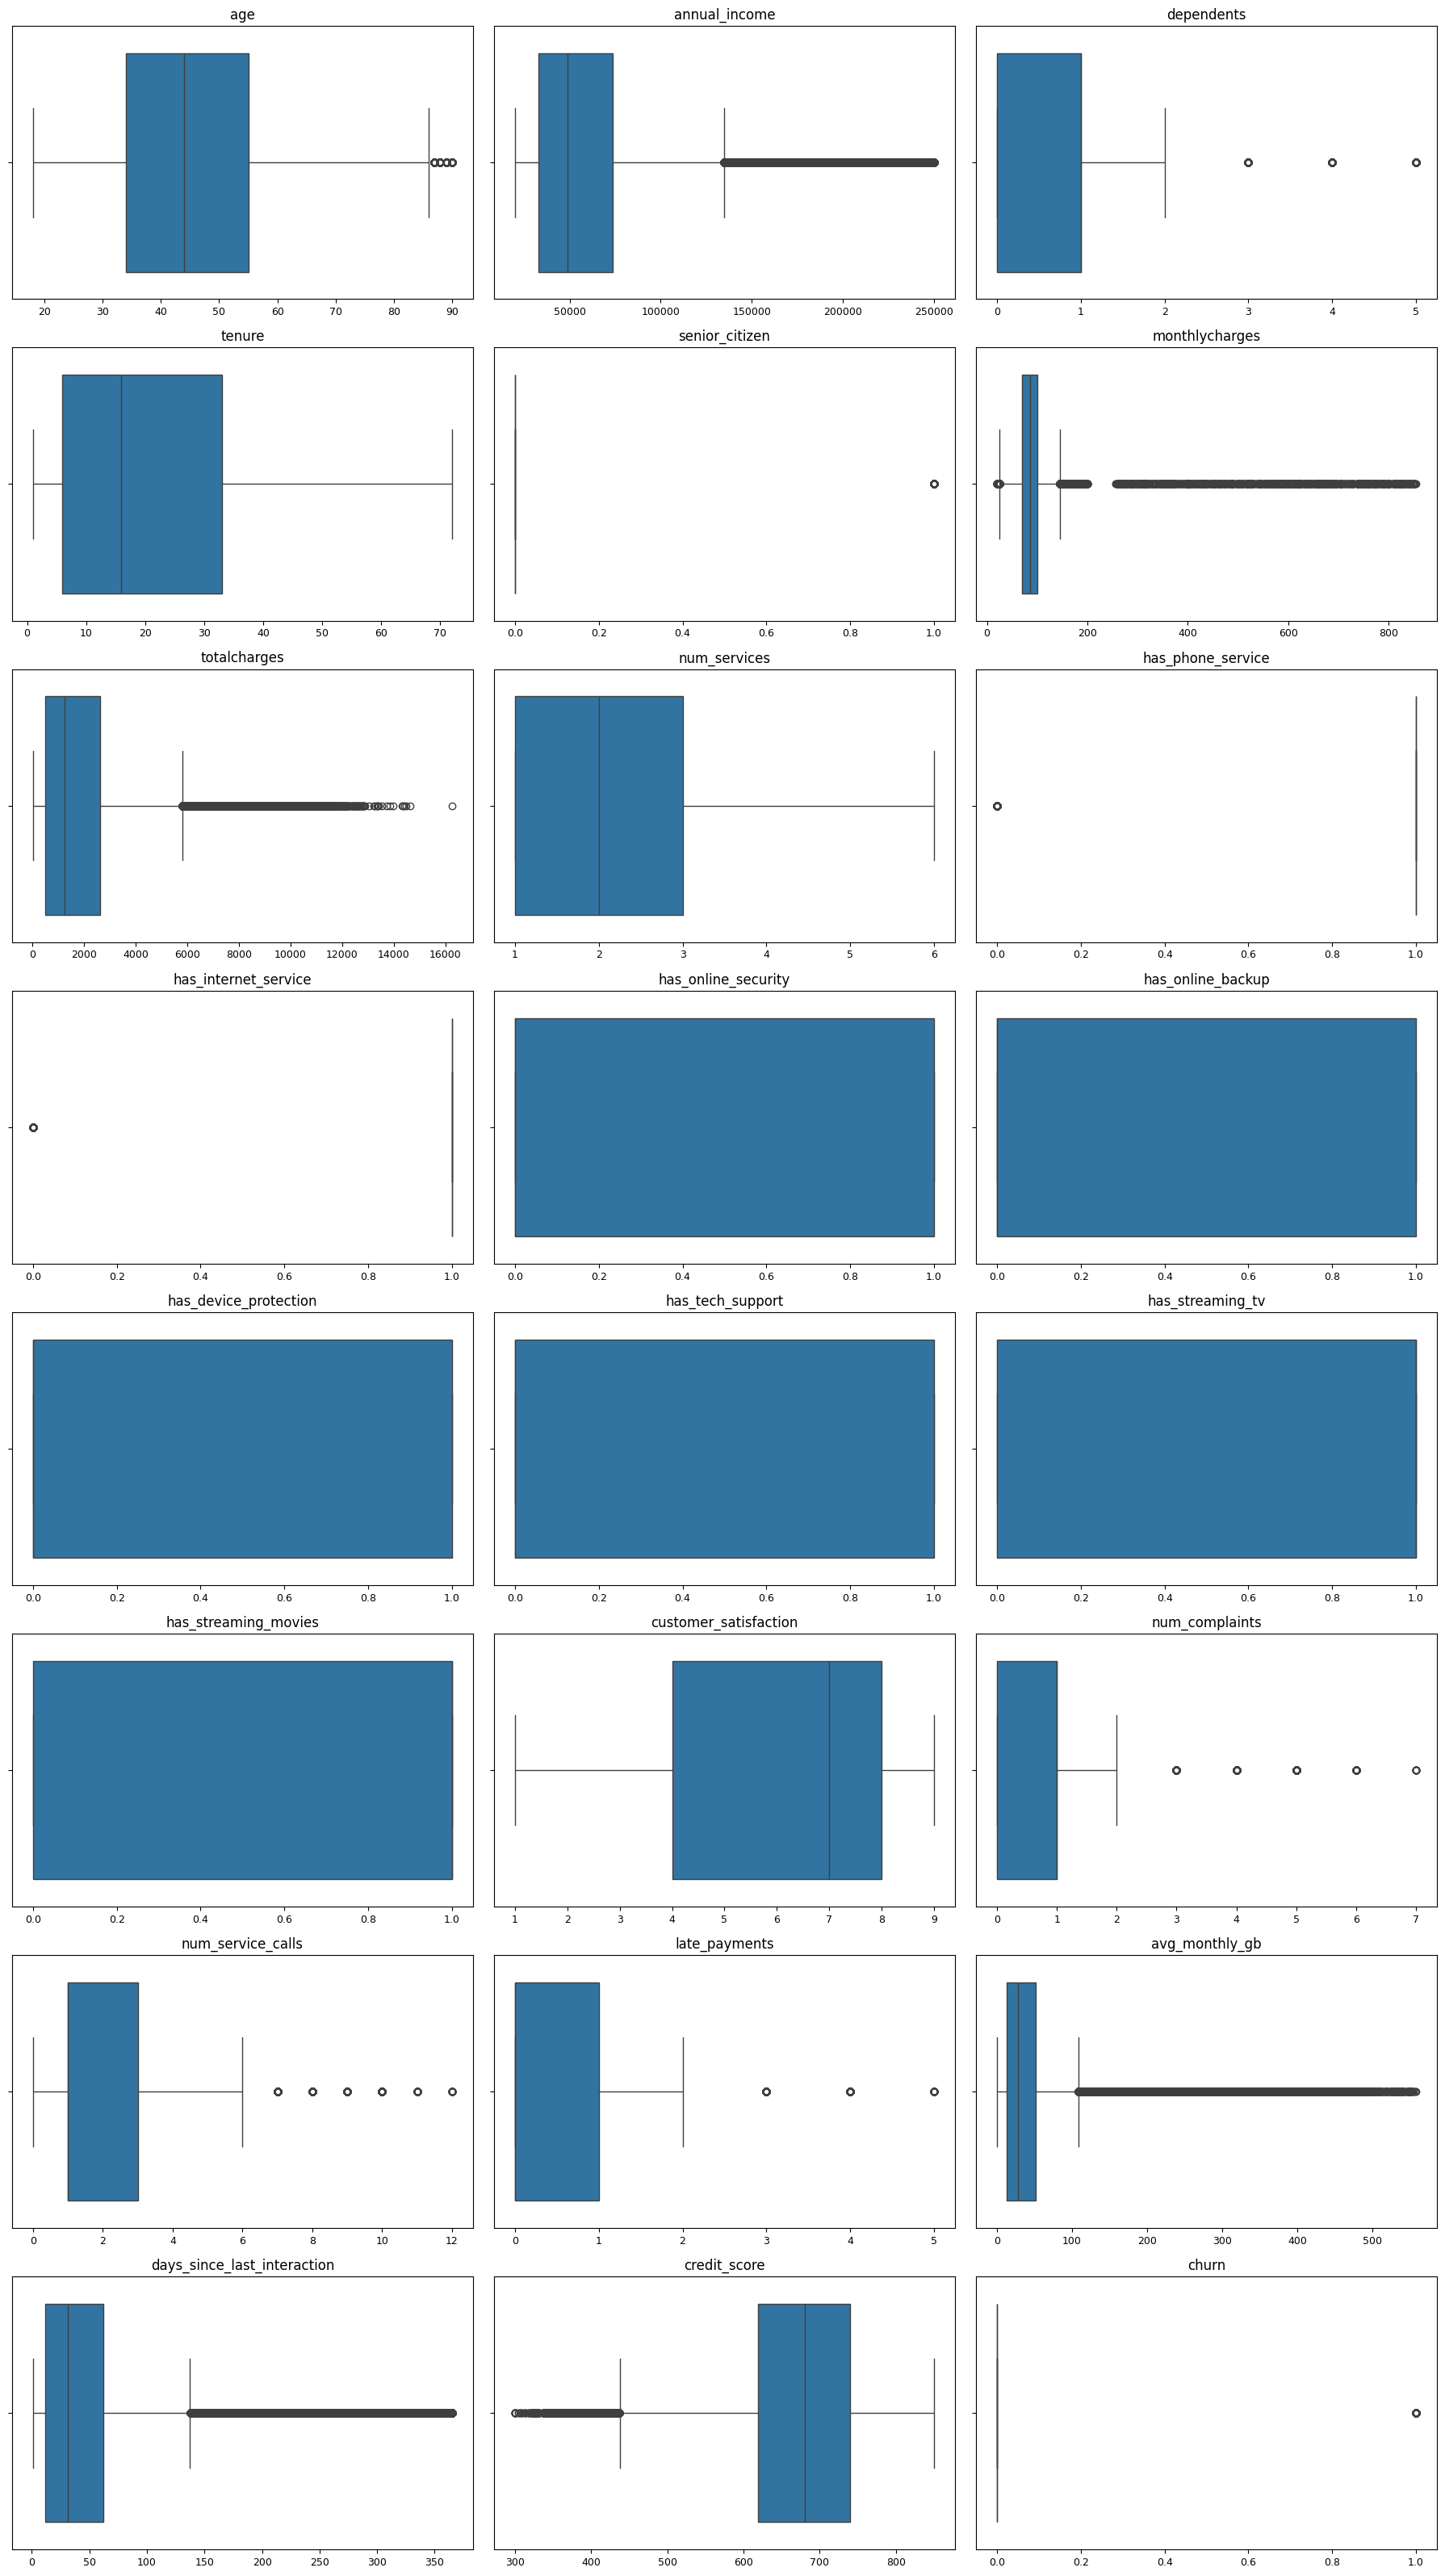

In [47]:
subplots = df.select_dtypes(include='number').columns
fig, axes = plt.subplots(
    nrows=8,
    ncols=3,
    figsize=(18, 32))
axes = axes.flatten()

for i, col in enumerate(subplots):
    sns.boxplot(
        x=df[col],
        ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=9)

for j in range(len(subplots), len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(
    hspace=0.6,
    wspace=0.3
)

plt.tight_layout()
plt.show()

# Target Variable Distribution

In [48]:
df['churn'].value_counts()

,count
churn,
0,900773
1,99227


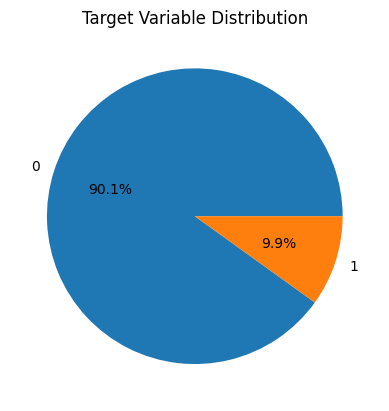

In [49]:
plt.pie(df['churn'].value_counts(), labels=df['churn'].value_counts().index, autopct='%1.1f%%')
plt.title('Target Variable Distribution')
plt.show()

# Feature Correlation

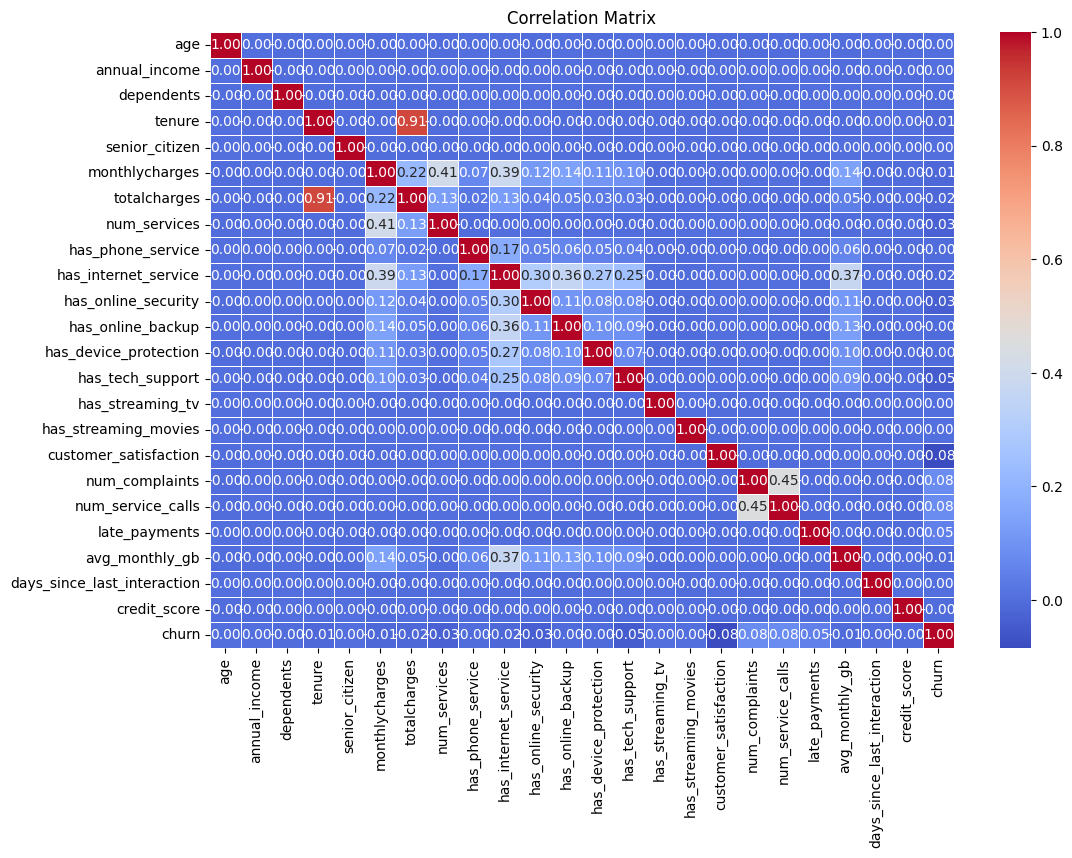

In [50]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [51]:
corr_matrix = df.select_dtypes(include='number').corr()
corr_matrix["churn"].sort_values(ascending = False)

,churn
churn,1.000000
num_complaints,0.079985
num_service_calls,0.077284
late_payments,0.047705
has_streaming_movies,0.001915
has_streaming_tv,0.000695
annual_income,0.000466
days_since_last_interaction,0.000391
senior_citizen,0.000344
age,0.000264


In [52]:
len(df.select_dtypes(include='object').columns)

7

# churn by Categorical Features

In [53]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(col, df[col].nunique())

signup_date 1000000
gender 3
education 5
marital_status 4
contract 3
payment_method 4
paperless_billing 2


In [54]:
cat_cols = cat_cols[1:]
cat_cols

Index(['gender', 'education', 'marital_status', 'contract', 'payment_method',
       'paperless_billing'],
      dtype='object')

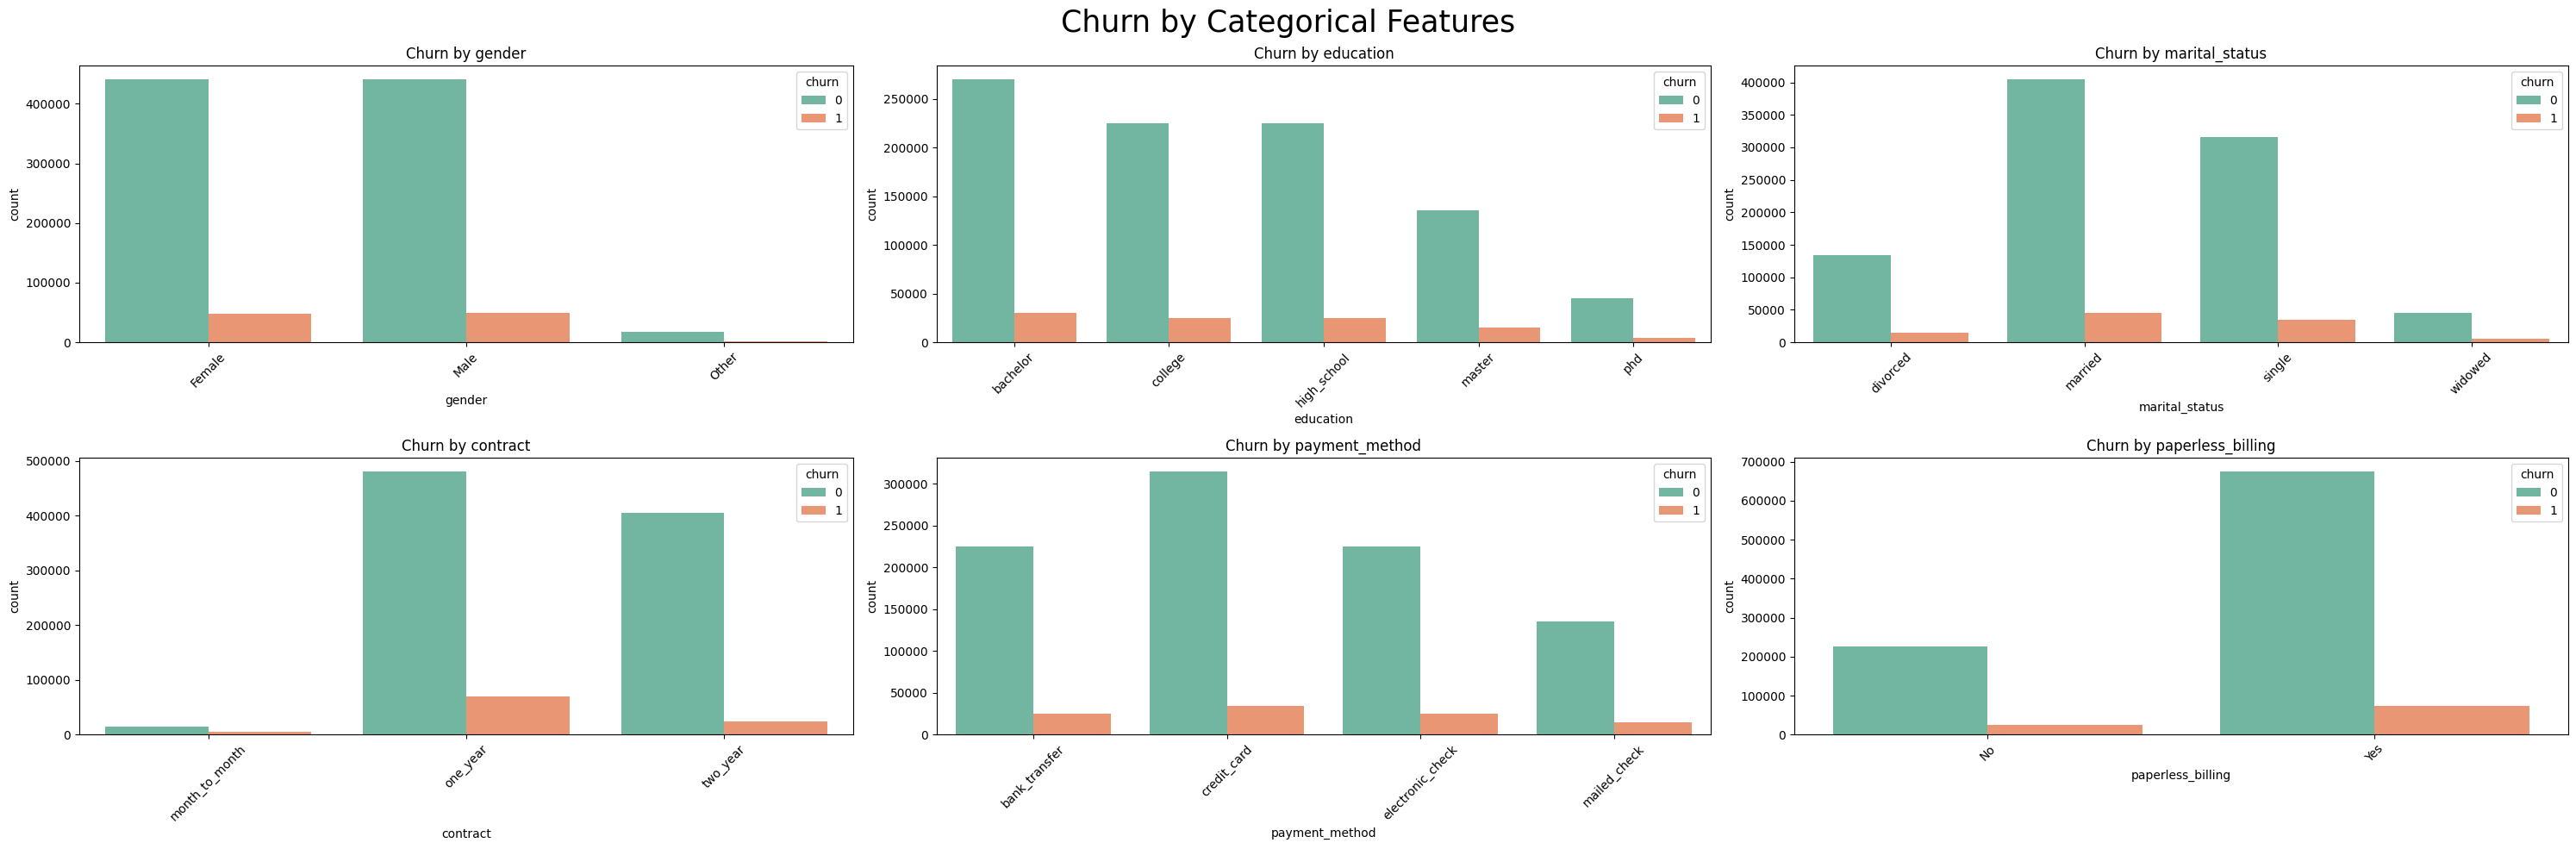

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(30, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    temp = (
        df.groupby([col, 'churn'])
        .size()
        .reset_index(name='count')
    )

    sns.barplot(
        data=temp,
        x=col,
        y='count',
        hue='churn',
        palette='Set2',
        ax=axes[i]
    )

    axes[i].set_title(f'Churn by {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Churn by Categorical Features', fontsize=25)
plt.tight_layout()
plt.show()

In [56]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class ChurnFeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.service_cols = [
            "has_online_security",
            "has_online_backup",
            "has_device_protection",
            "has_tech_support",
            "has_streaming_tv",
            "has_streaming_movies",
        ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        if "signup_date" in X_out.columns:
            X_out["signup_date"] = pd.to_datetime(X_out["signup_date"])
            X_out["signup_year"] = X_out["signup_date"].dt.year
            X_out["signup_month"] = X_out["signup_date"].dt.month
            X_out = X_out.drop(columns=["signup_date"])

        existing_service_cols = [
            c for c in self.service_cols if c in X_out.columns
        ]
        if existing_service_cols:
            X_out["total_active_services"] = X_out[existing_service_cols].sum(
                axis=1
            )

        if "tenure" in X_out.columns:
            X_out["complaint_ratio"] = np.where(
                X_out["tenure"] > 0, X_out["num_complaints"] / X_out["tenure"], 0
            )
            X_out["service_call_density"] = np.where(
                X_out["tenure"] > 0,
                X_out["num_service_calls"] / X_out["tenure"],
                0,
            )
            X_out["clv_estimate"] = X_out["monthlycharges"] * X_out["tenure"]

        if "num_services" in X_out.columns and "avg_monthly_gb" in X_out.columns:
            X_out["monthly_gb_per_service"] = np.where(
                X_out["num_services"] > 0,
                X_out["avg_monthly_gb"] / X_out["num_services"],
                0,
            )

        if (
            "late_payments" in X_out.columns
            and "customer_satisfaction" in X_out.columns
        ):
            X_out["is_high_risk_customer"] = (
                (X_out["late_payments"] > 0)
                & (X_out["customer_satisfaction"] <= 2)
            ).astype(int)

        return X_out

In [58]:
engineer = ChurnFeatureEngineer()
df_featured = engineer.fit_transform(df)

df_featured[["total_active_services", "complaint_ratio", "clv_estimate"]].head()

,total_active_services,complaint_ratio,clv_estimate
0,4,0.000000,134.40
1,2,0.000000,1573.88
2,3,0.333333,336.60
3,3,0.333333,644.94
4,1,0.111111,990.45
